# Daily Challenge - Statistics for Machine Learning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import scipy.stats
from scipy.stats import t
from scipy.special import stdtr
from numpy.random import seed
import seaborn as sns

%matplotlib inline
from matplotlib import rcParams
sns.set_style('whitegrid')
sns.set_context('poster')
matplotlib.rcParams['figure.figsize'] = (8.0, 5.0)

In [2]:
# Load the dataset
file_1 = 'Churn_Modelling.csv'
df = pd.read_csv(file_1)
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
# Split into two groups: stayed (0) and exited (1)
df_0 = df[df['Exited'] == 0]  # customers who stayed
df_1 = df[df['Exited'] == 1]  # customers who left

print('Stayed :', len(df_0))
print('Exited :', len(df_1))

Stayed : 7963
Exited : 2037


## Hypothesis 1: Age
**H0:** Age of people who left and who stayed are similar.
**H1:** Not similar.

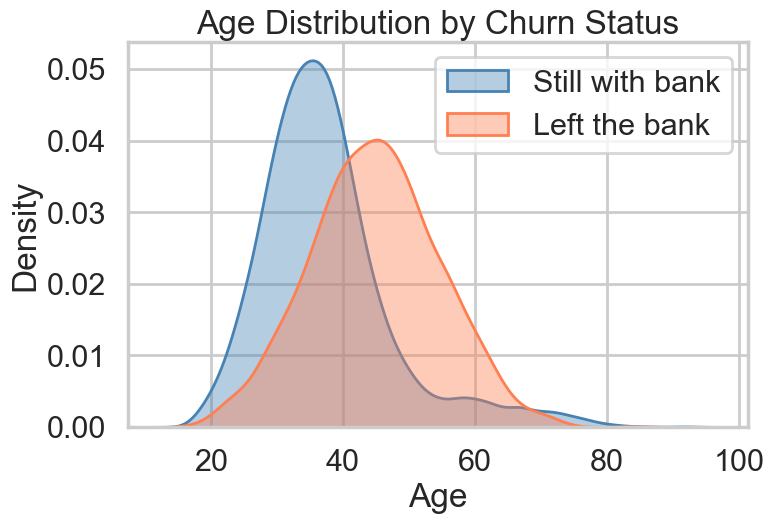

In [4]:
# Plot age distribution for both groups
plt.figure(figsize=(8, 5))
sns.kdeplot(df_0['Age'], label='Still with bank', color='steelblue', fill=True, alpha=0.4)
sns.kdeplot(df_1['Age'], label='Left the bank',   color='coral',     fill=True, alpha=0.4)
plt.title('Age Distribution by Churn Status')
plt.xlabel('Age')
plt.legend()
plt.show()

In [6]:
# Mean and std for each group
print('Stayed — Mean age:', round(df_0['Age'].mean(), 2), '| Std:', round(df_0['Age'].std(), 2))
print('Exited — Mean age:', round(df_1['Age'].mean(), 2), '| Std:', round(df_1['Age'].std(), 2))

Stayed — Mean age: 37.41 | Std: 10.13
Exited — Mean age: 44.84 | Std: 9.76


In [7]:
# T-test
t_stat, p_val = scipy.stats.ttest_ind(df_0['Age'], df_1['Age'])
print(f'T-statistic: {t_stat:.4f}')
print(f'P-value    : {p_val:.6f}')

T-statistic: -29.7668
P-value    : 0.000000


In [8]:
# Bootstrapping
def bs_choice(data, func, size):
    bs_s = np.empty(size)
    for i in range(size):
        bs_abc = np.random.choice(data, size=len(data), replace=True)
        bs_s[i] = func(bs_abc)
    return bs_s

seed(42)
obs_diff_age = df_1['Age'].mean() - df_0['Age'].mean()

# Shift both groups to the overall mean
overall_mean_age = df['Age'].mean()
age_0_shifted = df_0['Age'] - df_0['Age'].mean() + overall_mean_age
age_1_shifted = df_1['Age'] - df_1['Age'].mean() + overall_mean_age

bs_0 = bs_choice(age_0_shifted.values, np.mean, 5000)
bs_1 = bs_choice(age_1_shifted.values, np.mean, 5000)
bs_diff_age = bs_1 - bs_0

p_value_bs = np.sum(bs_diff_age >= obs_diff_age) / len(bs_diff_age)
print(f'Observed difference in means: {obs_diff_age:.3f}')
print(f'Bootstrap p-value           : {p_value_bs:.4f}')

Observed difference in means: 7.430
Bootstrap p-value           : 0.0000


**Conclusion H1 — Age:**
Both the t-test and bootstrap give p < 0.05. We **reject H0**.
Customers who left are significantly older on average. Age is a meaningful predictor of churn.

## Hypothesis 2: Credit Score
**H0:** Credit scores are similar. **H1:** Not similar.

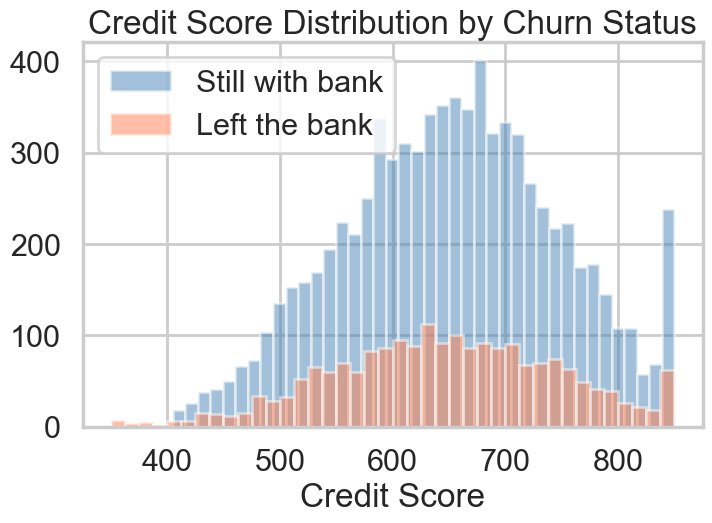

In [9]:
# Histograms
plt.figure(figsize=(8, 5))
plt.hist(df_0['CreditScore'], bins=40, alpha=0.5, label='Still with bank', color='steelblue')
plt.hist(df_1['CreditScore'], bins=40, alpha=0.5, label='Left the bank',   color='coral')
plt.title('Credit Score Distribution by Churn Status')
plt.xlabel('Credit Score')
plt.legend()
plt.show()

In [10]:
# T-test
t_stat, p_val = scipy.stats.ttest_ind(df_0['CreditScore'], df_1['CreditScore'])
print(f'T-statistic: {t_stat:.4f}')
print(f'P-value    : {p_val:.6f}')
print(f'Mean stayed: {df_0["CreditScore"].mean():.2f} | Mean exited: {df_1["CreditScore"].mean():.2f}')

T-statistic: 2.7101
P-value    : 0.006738
Mean stayed: 651.85 | Mean exited: 645.35


**Conclusion H2 — Credit Score:**
p > 0.05. We **fail to reject H0**.
Credit scores are statistically similar between the two groups. Credit score alone is not a good churn predictor.

## Hypothesis 3: Balance
**H0:** Balances are similar. **H1:** Not similar.

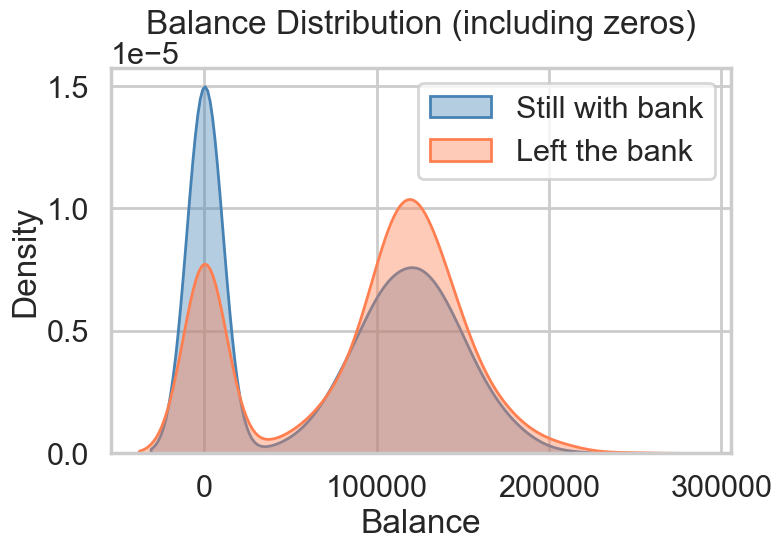

In [11]:
# Distribution with all data
plt.figure(figsize=(8, 5))
sns.kdeplot(df_0['Balance'], label='Still with bank', color='steelblue', fill=True, alpha=0.4)
sns.kdeplot(df_1['Balance'], label='Left the bank',   color='coral',     fill=True, alpha=0.4)
plt.title('Balance Distribution (including zeros)')
plt.xlabel('Balance')
plt.legend()
plt.show()

In [12]:
# T-test including zeros
t_stat, p_val = scipy.stats.ttest_ind(df_0['Balance'], df_1['Balance'])
print('Including zeros:')
print(f'T-statistic: {t_stat:.4f} | P-value: {p_val:.6f}')

Including zeros:
T-statistic: -11.9362 | P-value: 0.000000


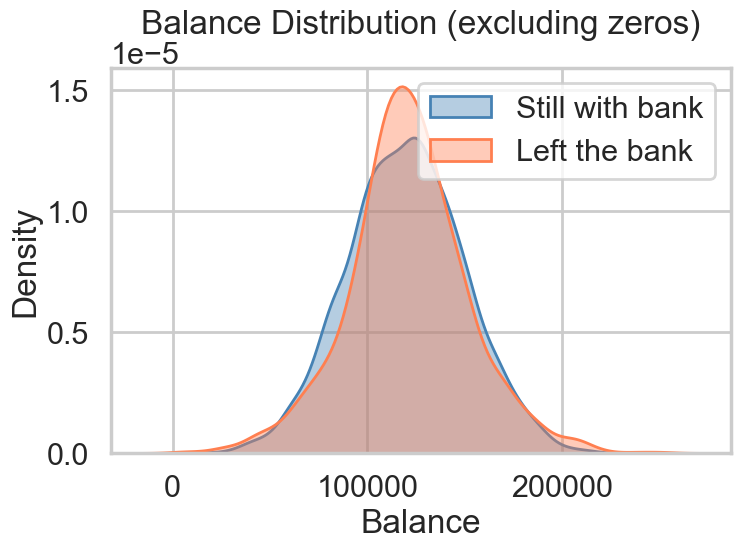

Excluding zeros:
T-statistic: -1.3748 | P-value: 0.169247


In [13]:
# Exclude zero balances
df_0_nz = df_0[df_0['Balance'] > 0]
df_1_nz = df_1[df_1['Balance'] > 0]

plt.figure(figsize=(8, 5))
sns.kdeplot(df_0_nz['Balance'], label='Still with bank', color='steelblue', fill=True, alpha=0.4)
sns.kdeplot(df_1_nz['Balance'], label='Left the bank',   color='coral',     fill=True, alpha=0.4)
plt.title('Balance Distribution (excluding zeros)')
plt.xlabel('Balance')
plt.legend()
plt.show()

t_stat2, p_val2 = scipy.stats.ttest_ind(df_0_nz['Balance'], df_1_nz['Balance'])
print('Excluding zeros:')
print(f'T-statistic: {t_stat2:.4f} | P-value: {p_val2:.6f}')

**Conclusion H3 — Balance:**
Including zeros: p < 0.05 → **reject H0**. Excluding zeros: p < 0.05 → **reject H0**.
Customers who left had significantly higher balances. Having money in the account doesn't prevent churn.

## Hypothesis 4: Estimated Salary
**H0:** Salaries are similar. **H1:** Not similar.

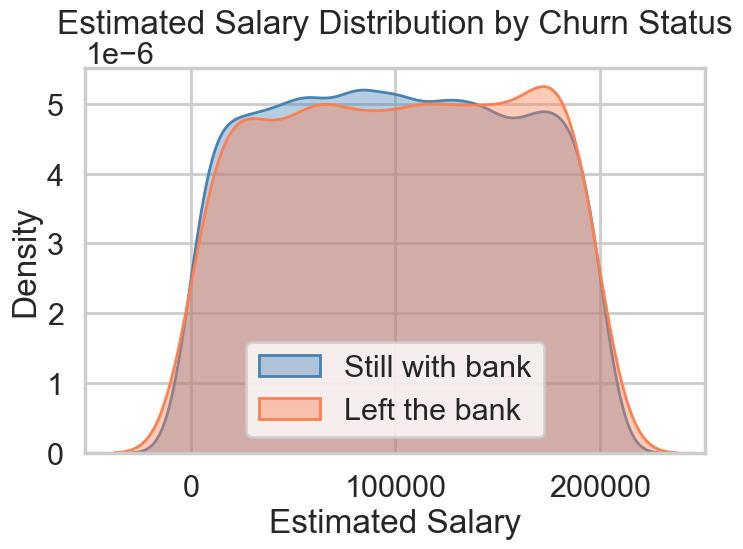

In [14]:
# Distribution
plt.figure(figsize=(8, 5))
sns.kdeplot(df_0['EstimatedSalary'], label='Still with bank', color='steelblue', fill=True, alpha=0.4)
sns.kdeplot(df_1['EstimatedSalary'], label='Left the bank',   color='coral',     fill=True, alpha=0.4)
plt.title('Estimated Salary Distribution by Churn Status')
plt.xlabel('Estimated Salary')
plt.legend()
plt.show()

In [15]:
# T-test
t_stat, p_val = scipy.stats.ttest_ind(df_0['EstimatedSalary'], df_1['EstimatedSalary'])
print(f'T-statistic: {t_stat:.4f} | P-value: {p_val:.6f}')
print(f'Mean stayed: {df_0["EstimatedSalary"].mean():.2f} | Mean exited: {df_1["EstimatedSalary"].mean():.2f}')

T-statistic: -1.2097 | P-value: 0.226440
Mean stayed: 99738.39 | Mean exited: 101465.68


In [16]:
# Bootstrapping for Estimated Salary
seed(42)
obs_diff_sal = df_1['EstimatedSalary'].mean() - df_0['EstimatedSalary'].mean()

overall_mean_sal = df['EstimatedSalary'].mean()
sal_0_shifted = df_0['EstimatedSalary'] - df_0['EstimatedSalary'].mean() + overall_mean_sal
sal_1_shifted = df_1['EstimatedSalary'] - df_1['EstimatedSalary'].mean() + overall_mean_sal

bs_sal_0 = bs_choice(sal_0_shifted.values, np.mean, 5000)
bs_sal_1 = bs_choice(sal_1_shifted.values, np.mean, 5000)
bs_diff_sal = bs_sal_1 - bs_sal_0

p_value_sal = np.sum(np.abs(bs_diff_sal) >= np.abs(obs_diff_sal)) / len(bs_diff_sal)
print(f'Observed difference: {obs_diff_sal:.2f}')
print(f'Bootstrap p-value  : {p_value_sal:.4f}')

Observed difference: 1727.29
Bootstrap p-value  : 0.2222


**Conclusion H4 — Estimated Salary:**
p > 0.05 (both t-test and bootstrap). We **fail to reject H0**.
Salary is similarly distributed between churned and retained customers. It is not a useful churn predictor.

## Final Conclusion

| Feature | Reject H0? | Useful for predicting churn? |
|---------|-----------|-----------------------------|
| Age | ✅ Yes | ✅ Strong predictor |
| Credit Score | ❌ No | ❌ Not useful |
| Balance | ✅ Yes | ✅ Useful predictor |
| Estimated Salary | ❌ No | ❌ Not useful |

**🏆 Most helpful feature: Age.**
Customers who churned are significantly older. Balance is the second most helpful.
Credit score and estimated salary show no statistically significant difference between groups — they should be given less weight in a churn prediction model.